1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


SystemExit: 0

C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


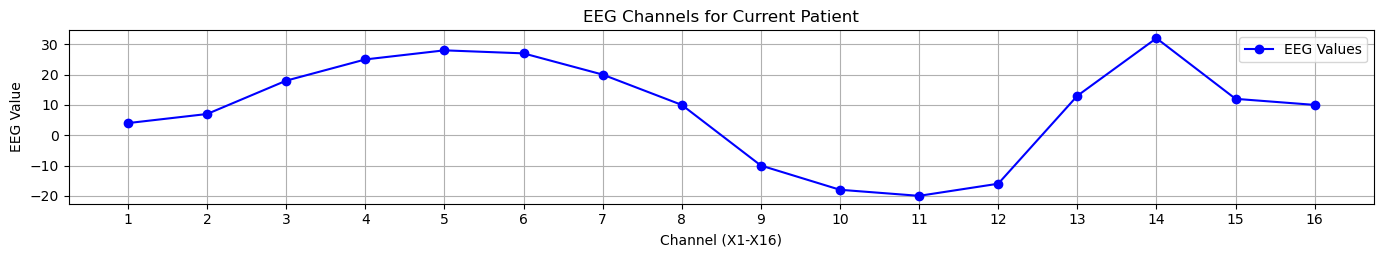

In [2]:
import sys
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import (
    QApplication, QWidget, QLabel, QLineEdit, QPushButton,
    QGridLayout, QVBoxLayout, QMessageBox, QFileDialog, QHBoxLayout
)
from PyQt5.QtGui import QMovie
from PyQt5.QtCore import Qt
from keras.models import load_model
from scipy.stats import mode
import matplotlib.pyplot as plt
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas

# Load trained models
model_spider = load_model("spider_model.h5")
model_ann = load_model("Ann_model.h5")

class_labels = ["Healthy (0)", "Generalized (1)", "Focal (2)", "Seizure Event (3)"]

class EEGVotingPredictor(QWidget):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("EEG Manual/CSV Input - Hard Voting (PyQt5)")
        self.setGeometry(100, 100, 1000, 800)

        self.inputs = []
        self.result_label = QLabel("")
        self.figure, self.ax = plt.subplots(figsize=(10, 6))
        self.canvas = FigureCanvas(self.figure)

        self.df = None
        self.current_index = 0

        self.initUI()

    def initUI(self):
        layout = QVBoxLayout()

        # Animated GIF
        gif_label = QLabel()
        gif_label.setAlignment(Qt.AlignCenter)
        movie = QMovie("pc.gif")  # Optional
        gif_label.setMovie(movie)
        movie.start()
        layout.addWidget(gif_label)

        # Grid of EEG inputs
        input_grid = QGridLayout()
        for i in range(16):
            label = QLabel(f"X{i+1}")
            entry = QLineEdit()
            self.inputs.append(entry)
            input_grid.addWidget(label, i // 8, (i % 8) * 2)
            input_grid.addWidget(entry, i // 8, (i % 8) * 2 + 1)
        layout.addLayout(input_grid)

        # Buttons
        btn_layout = QHBoxLayout()

        predict_btn = QPushButton("Predict")
        predict_btn.clicked.connect(self.predict)
        btn_layout.addWidget(predict_btn)

        load_btn = QPushButton("Load CSV")
        load_btn.clicked.connect(self.load_csv)
        btn_layout.addWidget(load_btn)

        prev_btn = QPushButton("Previous Patient")
        prev_btn.clicked.connect(self.prev_patient)
        btn_layout.addWidget(prev_btn)

        next_btn = QPushButton("Next Patient")
        next_btn.clicked.connect(self.next_patient)
        btn_layout.addWidget(next_btn)

        layout.addLayout(btn_layout)

        # Result label
        self.result_label.setStyleSheet("font-size: 16px; color: blue")
        layout.addWidget(self.result_label)

        # EEG Plot
        layout.addWidget(self.canvas)

        # Exit Button
        exit_btn = QPushButton("Exit")
        exit_btn.setStyleSheet("background-color: #f44336; color: white; font-size: 14px;")
        exit_btn.clicked.connect(self.close)
        layout.addWidget(exit_btn, alignment=Qt.AlignRight)

        self.setLayout(layout)

    def predict(self):
        try:
            values = [float(e.text()) for e in self.inputs]
            if len(values) != 16:
                raise ValueError("You must enter 16 EEG values.")

            eeg_input = np.array(values).reshape((16, 1)).astype(np.float32)
            input_tensor = np.expand_dims(eeg_input, axis=0)  # Shape: (1, 16, 1)

            # Predict with both models
            pred1 = model_spider.predict(input_tensor)[0]
            pred2 = model_ann.predict(input_tensor)[0]

            class1 = np.argmax(pred1)
            class2 = np.argmax(pred2)

            # Hard voting
            votes = np.array([class1, class2])
            final_class = mode(votes, keepdims=False).mode
            confidence = max(pred1[class1], pred2[class2]) * 100

            self.result_label.setText(
                f"Predicted Class: {class_labels[final_class]} ({confidence:.2f}%)"
            )
            self.plot_eeg(eeg_input)

        except Exception as e:
            QMessageBox.critical(self, "Input Error", str(e))

    def plot_eeg(self, eeg):
        self.ax.clear()
        x_axis = np.arange(1, 17)
        y_values = [eeg[i][0] for i in range(16)]
        self.ax.plot(x_axis, y_values, marker='o', linestyle='-', color='b', label="EEG Values")
        self.ax.set_title("EEG Channels for Current Patient")
        self.ax.set_xlabel("Channel (X1-X16)")
        self.ax.set_ylabel("EEG Value")
        self.ax.set_xticks(x_axis)
        self.ax.grid(True)
        self.ax.legend(loc="upper right")
        self.figure.tight_layout()
        self.canvas.draw()

    def load_csv(self):
        file_path, _ = QFileDialog.getOpenFileName(self, "Open EEG CSV", "", "CSV Files (*.csv)")
        if file_path:
            try:
                self.df = pd.read_csv(file_path)
                if self.df.shape[1] < 16:
                    raise ValueError("CSV must have at least 16 columns (X1 to X16).")
                self.current_index = 0
                self.load_sample(self.current_index)
            except Exception as e:
                QMessageBox.critical(self, "CSV Error", str(e))

    def load_sample(self, index):
        if self.df is not None and 0 <= index < len(self.df):
            row = self.df.iloc[index]
            for i in range(16):
                self.inputs[i].setText(str(row.iloc[i]))  # ← fixes the iloc warning
            self.predict()

    def next_patient(self):
        if self.df is not None and self.current_index < len(self.df) - 1:
            self.current_index += 1
            self.load_sample(self.current_index)

    def prev_patient(self):
        if self.df is not None and self.current_index > 0:
            self.current_index -= 1
            self.load_sample(self.current_index)

if __name__ == "__main__":
    app = QApplication(sys.argv)
    window = EEGVotingPredictor()
    window.show()
    sys.exit(app.exec_())
